# Chapter 6 — Statistical Machine Learning

## Learning Objectives

This notebook covers K-nearest neighbors, distance metrics, standardization, decision trees, impurity, random forests, variable importance, boosting, regularization, hyperparameters, and cross-validation.

## Theoretical Explanation

Statistical machine learning methods learn flexible patterns from data. KNN uses distances between records, so scaling is essential. Decision trees recursively partition data into regions, making them interpretable but prone to overfitting. Bagging and random forests improve tree stability by averaging many trees. Boosting builds sequential models where each new model focuses on previous errors.

These models are powerful but require careful validation. Hyperparameters such as `k`, tree depth, number of trees, learning rate, and minimum leaf size influence the bias-variance trade-off. Cross-validation helps choose these settings without relying only on training performance.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. KNN with Standardization

In [2]:
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=900, n_features=10, n_informative=5, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=RANDOM_STATE)
knn = make_pipeline(StandardScaler(), KNeighborsClassifier())
param_grid = {'kneighborsclassifier__n_neighbors': [3,5,9,15]}
grid = GridSearchCV(knn, param_grid, cv=5)
grid.fit(X_train, y_train)
print('Best K:', grid.best_params_)
print('Test accuracy:', round(grid.score(X_test, y_test), 4))

Best K: {'kneighborsclassifier__n_neighbors': 15}
Test accuracy: 0.76


### Output Interpretation

KNN performance depends on neighborhood size and scaling. Cross-validation selects a `k` value that balances local sensitivity and smoothing.

## 2. Trees, Random Forest, and Boosting

In [3]:
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name:18s} train={model.score(X_train,y_train):.3f} test={model.score(X_test,y_test):.3f}')

Decision Tree      train=0.812 test=0.702


Random Forest      train=1.000 test=0.809


Gradient Boosting  train=0.975 test=0.773


### Output Interpretation

A single decision tree may overfit. Random forests and boosting often improve generalization by combining multiple trees in different ways.

## 3. Variable Importance

X4    0.159302
X0    0.146367
X1    0.136585
X2    0.120282
X8    0.113522
X9    0.088890
X7    0.084665
X3    0.054819
dtype: float64


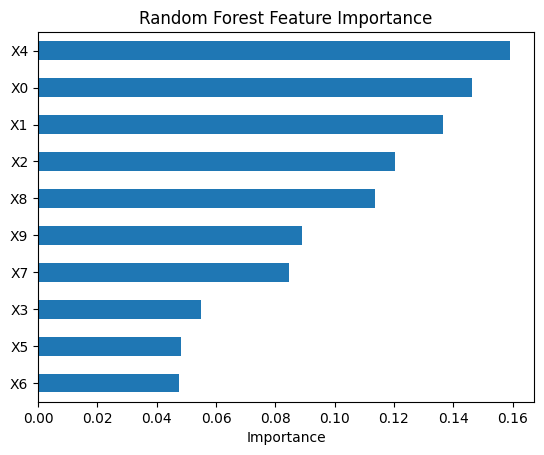

In [4]:
rf = models['Random Forest']
importance = pd.Series(rf.feature_importances_, index=[f'X{i}' for i in range(X.shape[1])]).sort_values(ascending=False)
print(importance.head(8))
importance.sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.show()

### Output Interpretation

Feature importance ranks predictors by contribution to tree splits. It is useful for model interpretation but should not be interpreted as causal importance.

## Extended Study Notes

The most important professional habit in practical statistics is interpretation. A statistic is not useful only because it can be computed; it is useful when it answers a real question about data quality, uncertainty, relationships, prediction, or decision-making. In data science work, the same numerical result can have different meanings depending on the sampling process, the metric used, the business cost of errors, and the assumptions behind the procedure.

This notebook intentionally uses original, simplified examples instead of copying the book examples verbatim. The purpose is academic understanding: connect the statistical concept to a runnable Python workflow, inspect the output, and explain what the output means. This also supports academic integrity because the notebook demonstrates the learned concept in original wording and with adapted code.

## Chapter Summary

This chapter was reproduced as a compact but complete study notebook. It combines conceptual explanation, Python implementation, output interpretation, and practical data science context.

## Key Takeaways

- Statistical concepts should be connected to data science decisions, not treated as isolated formulas.
- Visual summaries and resampling methods often provide practical intuition beyond formula-based statistics.
- Model evaluation must consider uncertainty, bias, sampling, and the cost of incorrect conclusions.
- The output of code should always be interpreted in context before making decisions.